# Vector Fields - Reactive Algorithms Pt 3. Saddle Points
## Saddle Point

Finding the Bifurcation Line, Riding the Bifurcation Line, and Staying on the saddle point

### Visualization of the Saddle Point

C:\Users\chris\AppData\Local\Temp\ipykernel_9120\156231812.py:33: RuntimeWarning: invalid value encountered in divide
  u_norm = u / magnitude
C:\Users\chris\AppData\Local\Temp\ipykernel_9120\156231812.py:34: RuntimeWarning: invalid value encountered in divide
  v_norm = v / magnitude


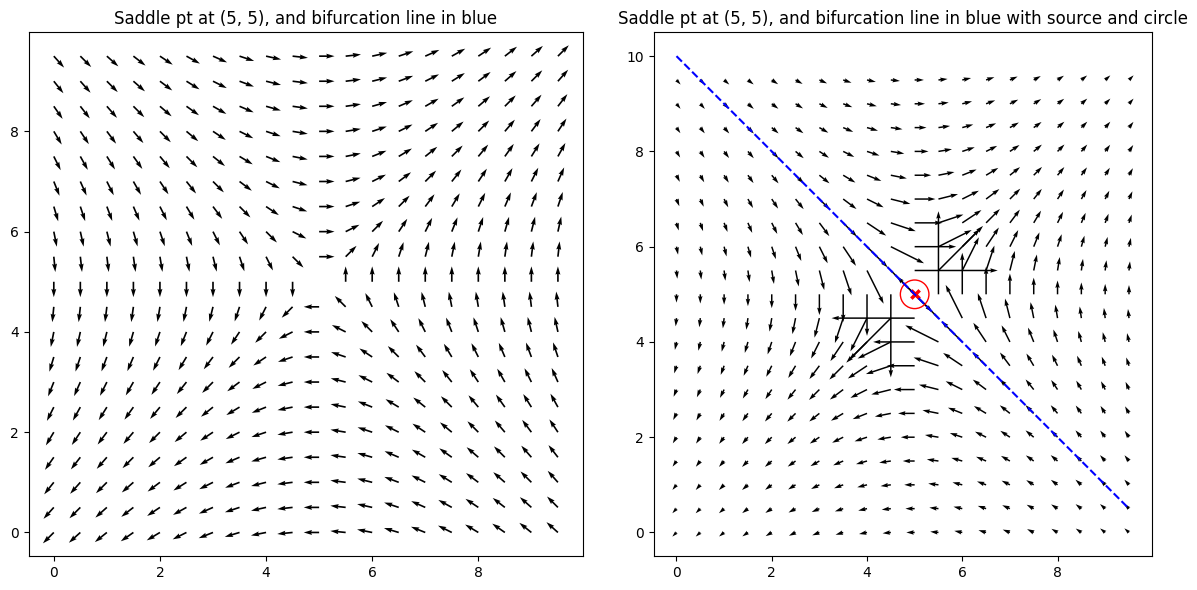

In [1]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

# Create Meshgrid
x = np.arange(0, 10, 0.5)
y = np.arange(0, 10, 0.5)
X, Y = np.meshgrid(x, y)

# Source Location
x_source = 5
y_source = 5

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Radial Distance from Centre
r = np.sqrt(x_centre**2 + y_centre**2)

# Avoid division by zero at the center
r[r==0] = 1e-6

# Calculate the angular component of the velocity
v_theta = 1 / r 

# Convert to cartesian coordinates
u = v_theta * y_centre / r
v = v_theta * x_centre / r

magnitude = (u**2 + v**2)**0.5

u_norm = u / magnitude
v_norm = v / magnitude

# Create the figure and the subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot the normalized vortex
axs[0].quiver(x, y, u_norm, v_norm)
axs[0].set_title("Saddle pt at (5, 5), and bifurcation line in blue")

# Plot the vortex
axs[1].quiver(x, y, u, v)

# Create circle
circle = plt.Circle((5,5), 0.3, color='red', fill=False)

# Add the circle to the plot
axs[1].add_patch(circle)

# Set aspect ratio to be equal, so the circle looks circular
axs[1].set_aspect('equal')

# Plot the Bifurcation Lines
axs[1].plot(x, (10-x), '--', color='blue')

# Add source point
axs[1].scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)

axs[1].set_title("Saddle pt at (5, 5), and bifurcation line in blue with source and circle")

# Show the plots
plt.tight_layout()
plt.show()


## Find the Separtrix and the Saddle Point

This algorithm has not been battletested

C:\Users\chris\AppData\Local\Temp\ipykernel_9120\2877026503.py:32: RuntimeWarning: invalid value encountered in divide
  u_norm = u / magnitude
C:\Users\chris\AppData\Local\Temp\ipykernel_9120\2877026503.py:33: RuntimeWarning: invalid value encountered in divide
  v_norm = v / magnitude


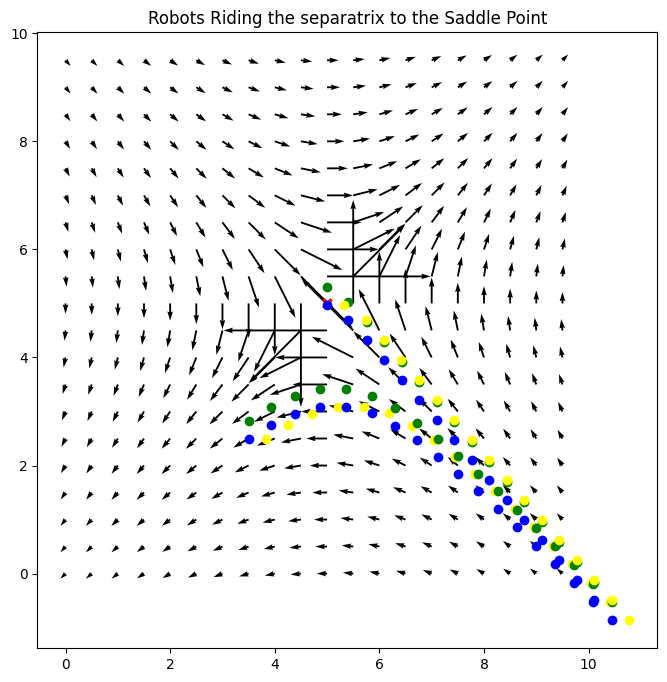

It took  17  steps to reach the Bifurcation line
It took  16  more steps to reach the Saddle Point


In [2]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve

# 1. Creating the Environment For Visualization

# Create Meshgrid
x = np.arange(0, 10, 0.5)
y = np.arange(0, 10, 0.5)
X, Y = np.meshgrid(x, y)

# Set Source Location
x_source = 5
y_source = 5

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Set Velocities at each point
r = np.sqrt(x_centre**2 + y_centre**2) # Radial Distance from Centre
r[r==0] = 1e-6

v_theta = 1 / r 

u = v_theta * y_centre / r
v = v_theta * x_centre / r

magnitude = (u**2 + v**2)**0.5

u_norm = u / magnitude
v_norm = v / magnitude

# 2. Initializing the robot positions

x1 = 3.5
y1 = 2.5
x2 = x1 + 0.33
y2 = y1
x3 = x1
y3 = y1+ 0.33
pos1 = [x1,y1]
pos2 = [x2,y2]
pos3 = [x3,y3]
step_size = 0.5
steps =0

plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)

# Plot each robot at Initialization
plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')

# 3. Algorithm to move towards Separatrix

for _ in range (1,30):
    # Vector Magnitude and Direction at Robot 1
    u_dist1 = pos1[0] - x_source
    v_dist1 = pos1[1] - y_source

    r1 = np.sqrt(u_dist1**2 + v_dist1**2) # Radial distance
    r1 = 1e-6 if r1 == 0 else r1

   
    v_theta1 = 1 / r1  # Calculate the velocity at distance r1 for any theta

    u1 =  v_theta1 * v_dist1 / r1  # Projecting into x and y
    v1 =  v_theta1 * u_dist1 / r1  # Projecting into x and y

    magnitude1 = (u1**2 + v1**2)**0.5
    angle1 = np.arctan2(-v1, -u1)


    # Vector Magnitude and Direction at Robot 2
    u_dist2 = pos2[0] - x_source
    v_dist2 = pos2[1] - y_source

    r2 = np.sqrt(u_dist2**2 + v_dist2**2) # Radial distance
    r2 = 1e-6 if r2 == 0 else r2

    # Calculate the velocity at distance r1 for any theta
    v_theta2 = 1 / r2

    # Projectcting into x and y
    u2 = v_theta2 * v_dist2 / r2
    v2 = v_theta2 * u_dist2 / r2

    magnitude2 = (u2**2 + v2**2)**0.5
    angle2 = np.arctan2(-v2, -u2)

    # Vector Magnitude and Direction at Robot 3
    u_dist3 = pos3[0] - x_source
    v_dist3 = pos3[1] - y_source

    r3 = np.sqrt(u_dist3**2 + v_dist3**2) # Radial distance
    r3 = 1e-6 if r3 == 0 else r3

    # Calculate the velocity at distance r1 for any theta
    v_theta3 = 1 / r3

    # Projectcting into x and y
    u3 = v_theta3 * v_dist3 / r3
    v3 = v_theta3 * u_dist3 / r3

    magnitude3 = (u3**2 + v3**2)**0.5
    angle3 = np.arctan2(-v3, -u3)

    
    # Computing Direction of the Bifurcation Line
    
    angle = (angle1 + angle2 + angle3) / 3 
    
 
    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
        
    steps += 1
    
  
    # Plot each robot
    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')
    
    # Break Criteria
    if np.std([angle1,angle2,angle3]) < 0.015:
        break

# 4. Ride the Separatrix

sad_steps = 0
for _ in range (1,30):

    # Break Condition
    if np.sign(angle1)==np.sign(angle2)==np.sign(angle3):
        pass
    else:
        break
    
    # Find Angle to Move
    slope_x = (magnitude2-magnitude1)/(x2-x1)
    slope_y = (magnitude3-magnitude1)/(y3-y1)
    slope_dir = np.arctan2(slope_y,slope_x)

    # Move in the Angle Found
    pos1[0] += step_size*np.cos(slope_dir)
    pos1[1] += step_size*np.sin(slope_dir)
    pos2[0] += step_size*np.cos(slope_dir)
    pos2[1] += step_size*np.sin(slope_dir)
    pos3[0] += step_size*np.cos(slope_dir)
    pos3[1] += step_size*np.sin(slope_dir)
    
    # Plot updated position of each robot
    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')
    sad_steps +=1

    # Update Robot Information

    # Vector Magnitude and Direction at Robot 1
    u_dist1 = pos1[0] - x_source
    v_dist1 = pos1[1] - y_source

    r1 = np.sqrt(u_dist1**2 + v_dist1**2) # Radial distance
    r1 = 1e-6 if r1 == 0 else r1


    v_theta1 = 1 / r1  # Calculate the velocity at distance r1 for any theta

    u1 =  v_theta1 * v_dist1 / r1  # Projecting into x and y
    v1 =  v_theta1 * u_dist1 / r1  # Projecting into x and y

    magnitude1 = (u1**2 + v1**2)**0.5
    angle1 = np.arctan2(-v1, -u1)


    # Vector Magnitude and Direction at Robot 2
    u_dist2 = pos2[0] - x_source
    v_dist2 = pos2[1] - y_source

    r2 = np.sqrt(u_dist2**2 + v_dist2**2) # Radial distance
    r2 = 1e-6 if r2 == 0 else r2

    # Calculate the velocity at distance r1 for any theta
    v_theta2 = 1 / r2

    # Projectcting into x and y
    u2 = v_theta2 * v_dist2 / r2
    v2 = v_theta2 * u_dist2 / r2

    magnitude2 = (u2**2 + v2**2)**0.5
    angle2 = np.arctan2(-v2, -u2)

    # Vector Magnitude and Direction at Robot 3
    u_dist3 = pos3[0] - x_source
    v_dist3 = pos3[1] - y_source

    r3 = np.sqrt(u_dist3**2 + v_dist3**2) # Radial distance
    r3 = 1e-6 if r3 == 0 else r3

    # Calculate the velocity at distance r1 for any theta
    v_theta3 = 1 / r3

    # Projectcting into x and y
    u3 = v_theta3 * v_dist3 / r3
    v3 = v_theta3 * u_dist3 / r3

    magnitude3 = (u3**2 + v3**2)**0.5
    angle3 = np.arctan2(-v3, -u3)
    


       
# 5. Visualize the output
plt.title("Robots Riding the separatrix to the Saddle Point")
plt.show()
print('It took ', steps, ' steps to reach the Bifurcation line' )
print('It took ', sad_steps, ' more steps to reach the Saddle Point' )